In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from sklearn.metrics import silhouette_score
from prettytable import PrettyTable
from sklearn.metrics import mean_squared_error


Prepare the Dataset for applying K-means 

C:\Users\fzmaj\AppData\Local\Temp\ipykernel_20848\138807846.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Dset['CheckInHour'] = pd.to_datetime(Dset['CheckInTime']).dt.hour
C:\Users\fzmaj\AppData\Local\Temp\ipykernel_20848\138807846.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Dset['CheckOutHour'] = pd.to_datetime(Dset['CheckOutTime']).dt.hour


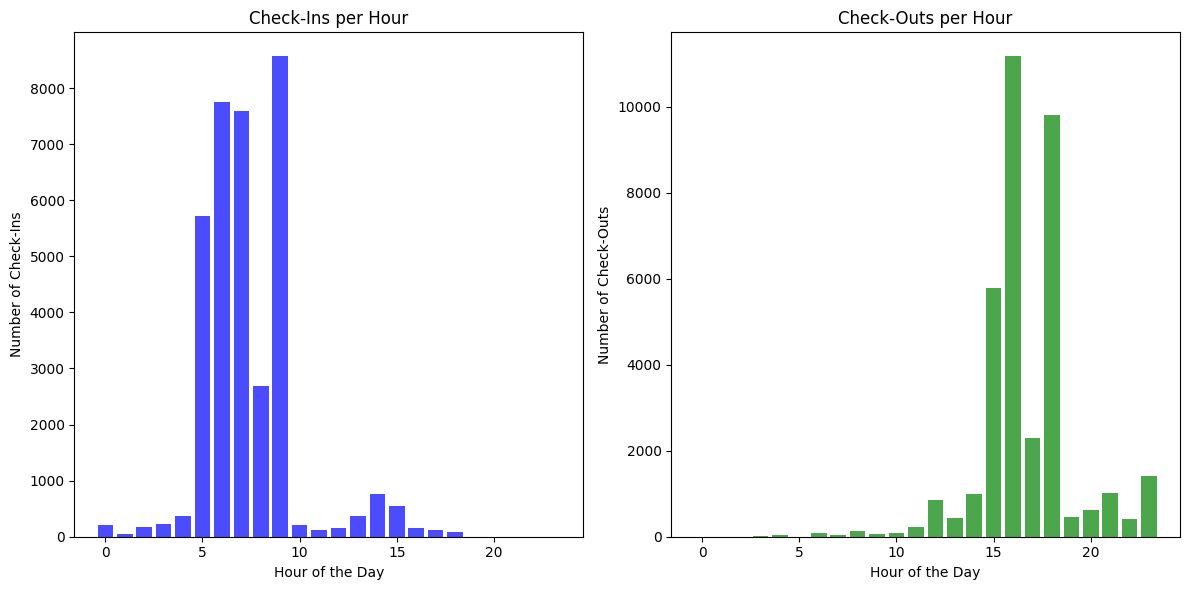

In [6]:
# Load the transformation dataset for the client 3272_aldella'
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/processed/3272_aldella'))
csv_file = '3272_aldella_transformation_data.csv'
absolute_path = os.path.join(get_base_dir, csv_file)
Dset = pd.read_csv(absolute_path)

# Convert 'CheckInTime' and 'CheckOutTime' to hours 
Dset['CheckInHour'] = pd.to_datetime(Dset['CheckInTime']).dt.hour 
Dset['CheckOutHour'] = pd.to_datetime(Dset['CheckOutTime']).dt.hour 


# Convert CheckInTime to minutes since midnight
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h * 60 + m + s / 60  # Convert seconds to minutes

Dset['CheckInMinutes'] = Dset['CheckInTime'].apply(time_to_minutes)
Dset['CheckOutMinutes'] = Dset['CheckOutTime'].apply(time_to_minutes)

# Count checkinHours per hour
check_in_counts = Dset['CheckInHour'].value_counts().sort_index()

# Count CheckOutHour per hour
check_out_counts = Dset['CheckOutHour'].value_counts().sort_index()

# Create a DataFrame for plotting
hours = range(24)
check_in_counts = check_in_counts.reindex(hours, fill_value=0)
check_out_counts = check_out_counts.reindex(hours, fill_value=0)

# Plot results
plt.figure(figsize=(12, 6))

# Plot CheckInHour counts
plt.subplot(1, 2, 1)
plt.bar(check_in_counts.index, check_in_counts.values, color='blue', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Ins')
plt.title('Check-Ins per Hour')

# Plot CheckOutHour counts
plt.subplot(1, 2, 2)
plt.bar(check_out_counts.index, check_out_counts.values, color='green', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Outs')
plt.title('Check-Outs per Hour')
plt.tight_layout()
plt.show()


Applying K-means clustering 
 1- Create feature Engineering: select CheckInHour &  CheckOutHour to Create features 
 2- Normalization: Standardizes features by removing the mean and scaling to unit variance.
In our case K is not define, will claculate the umber of clusters for K-Means clustering using the silhouette score

In [7]:
# Feature engineering: select CheckInMinutes &  CheckInMinutes to Create features 
Dset_features = Dset[['CheckInMinutes', 'CheckOutMinutes']].values
 # Normalize features
Dset_features = StandardScaler().fit_transform(Dset_features) 

# K-Means Clustering - this function return the optimal k means 
def optimal_k_means(Dset_features):
    silhouette_scores = []
    k_range = range(2, 11) # setup the range of K form 2 to 11
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(Dset_features)
        labels = kmeans.labels_
        silhouette_avg = silhouette_score(Dset_features, labels)
        silhouette_scores.append(silhouette_avg)
    optimal_k = k_range[np.argmax(silhouette_scores)]
    return optimal_k  

#get the optimal K
optimal_k = optimal_k_means(Dset_features)
# implement K-means clustering 
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
#computes the centroids and assigns clusters/ assigns each data point to the nearest cluster
Dset['cluster'] = kmeans.fit_predict(Dset_features) 

K-means claustring resualt visualization 

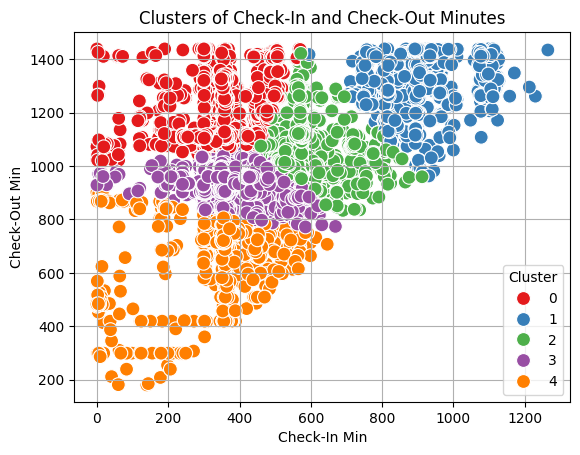

In [8]:
sns.scatterplot(x='CheckInMinutes', y='CheckOutMinutes', hue=Dset['cluster'], data=Dset, palette='Set1', s=100)
plt.title('Clusters of Check-In and Check-Out Minutes')
plt.xlabel('Check-In Min')
plt.ylabel('Check-Out Min')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

Calculate silhouette score

In [9]:
silhouette_avg = silhouette_score(Dset_features, Dset['cluster'])
print(silhouette_avg)

0.5467112787469854


Calculate the variance and MSE 

In [10]:
# Calculate variance and MSE
def calculate_variance_and_mse(df, cluster_col, feature_cols):
    cluster_variance = {}
    cluster_mse = {}
    
    for cluster in df[cluster_col].unique():
        cluster_data = df[df[cluster_col] == cluster]
        
        # Calculate variance
        variance = cluster_data[feature_cols].var()
        cluster_variance[cluster] = variance.tolist()
        
        # Calculate MSE
        # MSE calculation requires comparison of actual values to some prediction or mean
        cluster_mean = cluster_data[feature_cols].mean().values
        mse = np.mean([
            mean_squared_error(cluster_data[feature_col], [cluster_mean[i]] * len(cluster_data))
            for i, feature_col in enumerate(feature_cols)
        ])
        cluster_mse[cluster] = mse
    
    return cluster_variance, cluster_mse

# Calculate variance and MSE
variance, mse = calculate_variance_and_mse(Dset, 'cluster', ['CheckInMinutes', 'CheckOutMinutes'])

# Print results
print("Variance by Cluster:")
for cluster, var in variance.items():
    print(f"Cluster {cluster}: {var}")

print("\nMSE by Cluster:")
for cluster, mse_val in mse.items():
    print(f"Cluster {cluster}: {mse_val}")

# Convert variance to standard deviation
def calculate_standard_deviation(variance_values):
    return np.sqrt(variance_values)



Variance by Cluster:
Cluster 2: [1359.278409358616, 3551.4914919045573]
Cluster 3: [3262.673366925525, 1623.8181834215309]
Cluster 4: [15818.769939366079, 16413.44597242393]
Cluster 0: [7737.400568161841, 8409.416746184885]
Cluster 1: [7284.306204189001, 10929.760229828838]

MSE by Cluster:
Cluster 2: 2455.13948577598
Cluster 3: 2443.1056808056856
Cluster 4: 16106.599927602441
Cluster 0: 8071.660787795321
Cluster 1: 9102.759620942748


Visualize the variance and the MSE

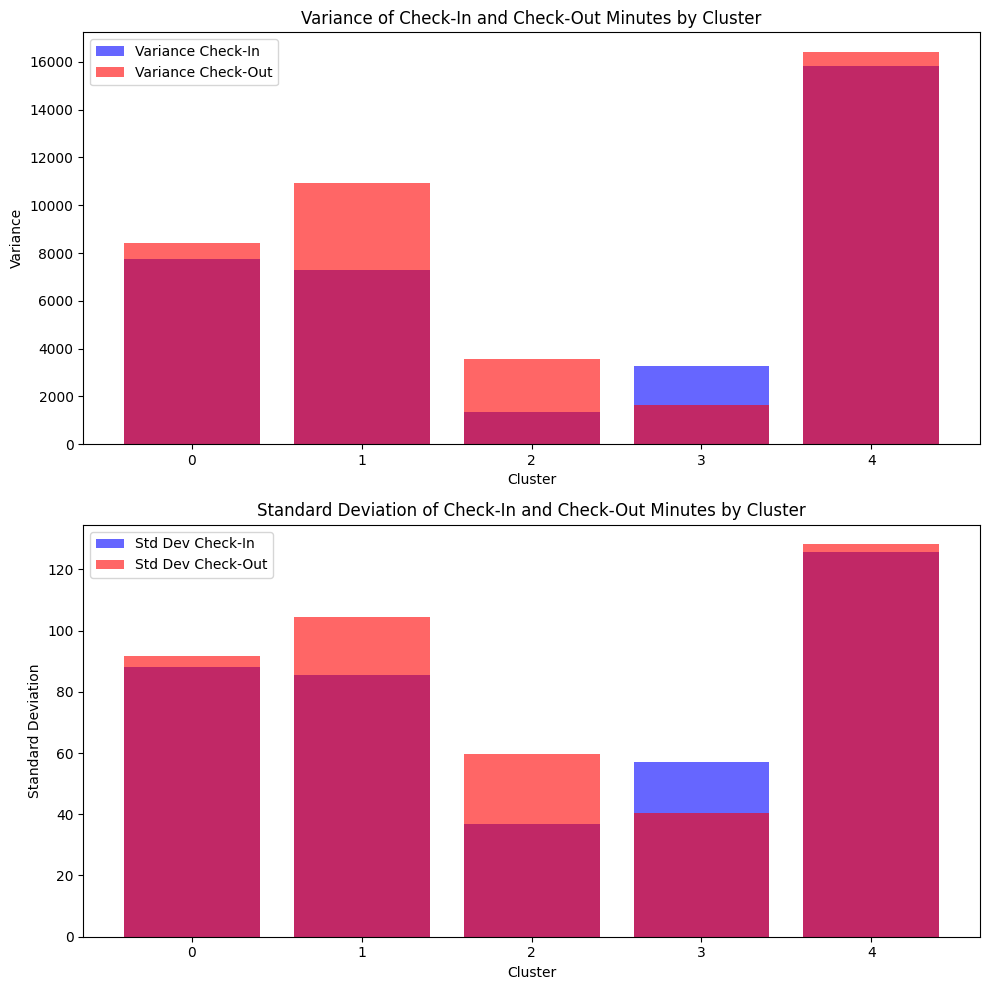

In [11]:
# Lists to store data for plotting
clusters = []
variances_check_in = []
variances_check_out = []
std_devs_check_in = []
std_devs_check_out = []

# Process data
for cluster, (variance_check_in, variance_check_out) in variance.items():
    std_dev_check_in = calculate_standard_deviation(variance_check_in)
    std_dev_check_out = calculate_standard_deviation(variance_check_out)
    
   # Append data for plotting
    clusters.append(cluster)
    variances_check_in.append(variance_check_in)
    variances_check_out.append(variance_check_out)
    std_devs_check_in.append(std_dev_check_in)
    std_devs_check_out.append(std_dev_check_out)

# Plotting
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

# Variance Plot
ax[0].bar(clusters, variances_check_in, color='b', alpha=0.6, label='Variance Check-In')
ax[0].bar(clusters, variances_check_out, color='r', alpha=0.6, label='Variance Check-Out')
ax[0].set_title('Variance of Check-In and Check-Out Minutes by Cluster')
ax[0].set_xlabel('Cluster')
ax[0].set_ylabel('Variance')
ax[0].legend()

# Standard Deviation Plot
ax[1].bar(clusters, std_devs_check_in, color='b', alpha=0.6, label='Std Dev Check-In')
ax[1].bar(clusters, std_devs_check_out, color='r', alpha=0.6, label='Std Dev Check-Out')
ax[1].set_title('Standard Deviation of Check-In and Check-Out Minutes by Cluster')
ax[1].set_xlabel('Cluster')
ax[1].set_ylabel('Standard Deviation')
ax[1].legend()

plt.tight_layout()
plt.show()

 Calculate statistics for K-means clausters
- find the range of check in and check out for every cluster and the mean hours for both.

In [17]:
# Calculate start and end hours for each cluster
# Calculate statistics for each cluster
Dset['Cluster'] = kmeans.fit_predict(Dset_features)
cluster_summary = Dset.groupby('Cluster').agg({
    'CheckInMinutes': ['mean', 'min', 'max'],
    'CheckOutMinutes': ['mean', 'min', 'max']
}).reset_index()
# Flatten MultiIndex columns
cluster_summary.columns = ['Cluster', 'CheckInMinutes_Mean', 'CheckInMinutes_Min', 'CheckInMinutes_Max',
                           'CheckOutMinutes_Mean', 'CheckOutMinutes_Min', 'CheckOutMinutes_Max']
# Print the summary
# Convert DataFrame to PrettyTable

clusters_table = PrettyTable()
clusters_table.field_names = cluster_summary.columns
for row in cluster_summary.itertuples(index=False):
    clusters_table.add_row(row)
# Print the table
print(clusters_table)

+---------+---------------------+--------------------+--------------------+----------------------+---------------------+---------------------+
| Cluster | CheckInMinutes_Mean | CheckInMinutes_Min | CheckInMinutes_Max | CheckOutMinutes_Mean | CheckOutMinutes_Min | CheckOutMinutes_Max |
+---------+---------------------+--------------------+--------------------+----------------------+---------------------+---------------------+
|    0    |  377.84910153712923 |        0.0         |       571.0        |  1157.8965143970556  |        1020.0       |        1439.0       |
|    1    |  900.5344908493665  |       595.0        |       1265.0       |  1338.035664007508   |        961.0        |        1439.0       |
|    2    |  562.9711086673998  |       452.0        |       913.0        |  1093.4702589223234  |        834.0        |        1422.0       |
|    3    |  405.5448967889908  |        0.0         |       669.0        |  950.9354357798165   |        761.0        |        1061.0       |

The heatmap of Check-In & Check-out hours range for each cluster

In [ ]:
#Pivot the summary for heatmap
heatmap_data = cluster_summary.set_index('Cluster')
heatmap_data = heatmap_data[['CheckInMinutes_Min', 'CheckInMinutes_Max', 'CheckOutMinutes_Min', 'CheckOutMinutes_Max']]
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Check-In and Check-Out Minutes Ranges by Cluster')
plt.xlabel('Minutes Type')
plt.ylabel('Cluster')
plt.show()

Sace the K-Means Clustring result to csv file

In [14]:

# Save K_means result CSV file
output_dir = '../../data/processed/3272_aldella'
os.makedirs(output_dir, exist_ok=True)
Dset.to_csv(os.path.join(output_dir, '3272_aldella_K_means_clustring_result.csv'), index=False)

Apply some statistics identify the clusters 
1- count the number of employees in each cluster(shift)
2- identify the employees who attend multible shift
3-Plot the number of employees in each cluster

total_employees 171
percentage_multiple_clusters 84.21052631578947
Number of employees attending multiple clusters: 144
Percentage of employees attending multiple clusters: 84.21%


C:\Users\fzmaj\AppData\Local\Temp\ipykernel_20848\1637267013.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='EmployeeCount', data=cluster_counts, palette='Set2')


Text(0, 0.5, 'Number of Employees')

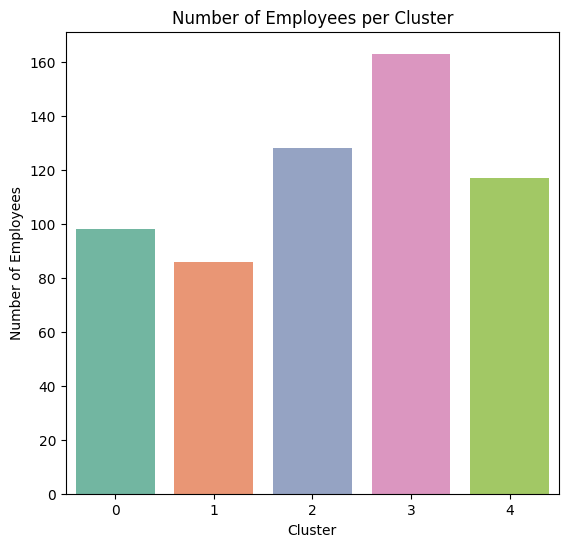

In [15]:
# Count the number of employees in each cluster
cluster_counts = Dset.groupby('Cluster')['EmployeeId'].nunique().reset_index(name='EmployeeCount')

# Identify employees who attend multiple shifts
employee_clusters = Dset.groupby('EmployeeId')['Cluster'].nunique().reset_index()
employees_multiple_clusters = employee_clusters[employee_clusters['Cluster'] > 1]
num_employees_multiple_clusters = employees_multiple_clusters.shape[0]
total_employees = Dset['EmployeeId'].nunique()
percentage_multiple_clusters = (num_employees_multiple_clusters / total_employees) * 100

print("total_employees",total_employees)

print('percentage_multiple_clusters',percentage_multiple_clusters)

# Print number and percentage of employees attending multiple clusters
print(f"Number of employees attending multiple clusters: {num_employees_multiple_clusters}")
print(f"Percentage of employees attending multiple clusters: {percentage_multiple_clusters:.2f}%")

# Plot the number of employees in each cluster
plt.figure(figsize=(14, 6))

# Bar plot for number of employees per cluster
plt.subplot(1, 2, 1)
sns.barplot(x='Cluster', y='EmployeeCount', data=cluster_counts, palette='Set2')
plt.title('Number of Employees per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Employees')

